In [12]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load image
img = cv2.imread("/content/Screenshot 2026-03-02 140058.png")
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

In [13]:
#Remove Noise
blur = cv2.GaussianBlur(gray, (5,5), 0)

In [14]:
ret, thresh = cv2.threshold(blur, 0, 255,cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

In [15]:
kernel = np.ones((3,3), np.uint8)
opening = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=2)

In [16]:
sure_bg = cv2.dilate(opening, kernel, iterations=3)

In [17]:
dist_transform = cv2.distanceTransform(opening, cv2.DIST_L2, 5)
ret, sure_fg = cv2.threshold(dist_transform,0.7 * dist_transform.max(), 255, 0)

In [18]:
sure_fg = np.uint8(sure_fg)
unknown = cv2.subtract(sure_bg, sure_fg)

In [19]:
#Marker Labelling
ret, markers = cv2.connectedComponents(sure_fg)
markers = markers + 1
markers[unknown == 255] = 0

In [20]:
#Apply Watershed
markers = cv2.watershed(img, markers)

# Mark boundary in red
img[markers == -1] = [255, 0, 0]

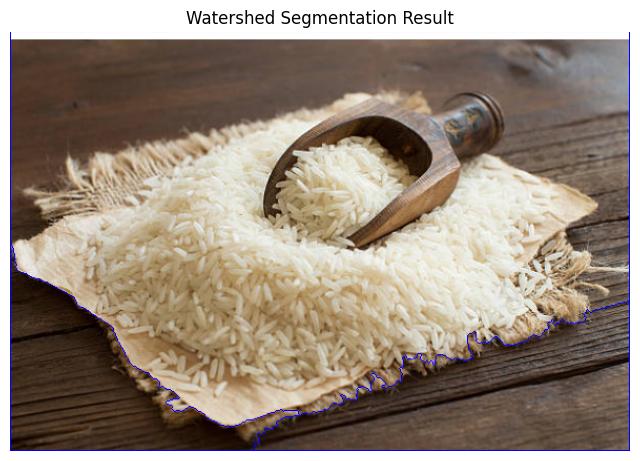

In [21]:
plt.figure(figsize=(8,6))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Watershed Segmentation Result")
plt.axis("off")
plt.show()